In [5]:
# Force the working directory to be the one of the Github repo
import os
os.chdir("/home/robinr/Desktop/VSCode/CIRAD_PhD_Robin")
print("Working dir:", os.getcwd())

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

Working dir: /home/robinr/Desktop/VSCode/CIRAD_PhD_Robin


[INFO] Loaded CSV file: Results/assoc_pp_model/LUCAS_SOC_all_26650_NocitaKS/results_LUCAS_SOC_all_26650_NocitaKS_progressive_optim_10000_epc_1000_ptc.csv
[INFO] DataFrame shape: (4, 68)


/tmp/ipykernel_1479206/1766231471.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.at[idx, col] = ""
/tmp/ipykernel_1479206/1766231471.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.at[idx, col] = ""
/tmp/ipykernel_1479206/1766231471.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.at[idx, col] = ""
/tmp/ipykernel_1479206/1766231471.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an e

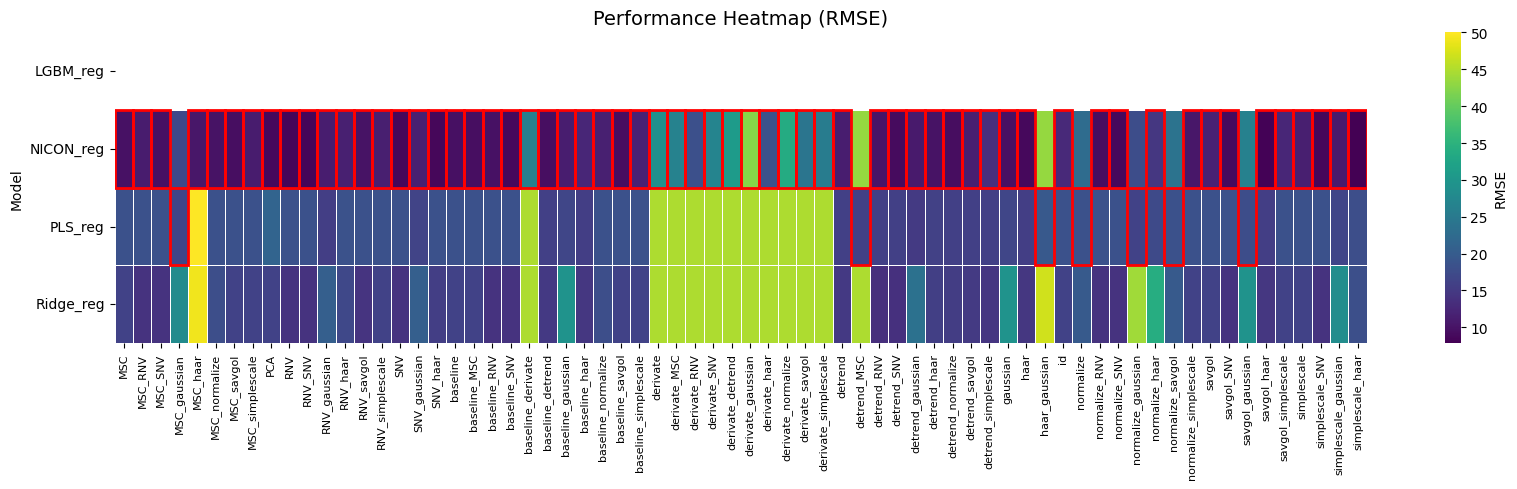

[INFO] Heatmap saved to: Figures/assoc_pp_model/LUCAS_SOC_all_26650_NocitaKS/heatmap_LUCAS_SOC_all_26650_NocitaKS_progressive_optim_10000_epc_1000_ptc.png


In [13]:
# ---------------------------------------------------
# Script to generate a heatmap of performances
# from an already saved CSV file (pivoted format).
# ---------------------------------------------------

# === USER INPUT: path to the CSV file ===
mode = "Regression"  # "Regression" or "Classification"
name_dataset = "LUCAS_SOC_all_26650_NocitaKS"
type_optim = "progressive_optim" # "progressive_optim" or "uniform_optim"
csv_path = f"Results/assoc_pp_model/{name_dataset}/results_{name_dataset}_{type_optim}_10000_epc_1000_ptc.csv"
only_colors = True  # If True → heatmap without numbers
top_n = None  # Keep None to show all preprocessings, or set a number to filter the top-N

# === Load the CSV file ===
df = pd.read_csv(csv_path, index_col=0)  # index = Model, columns = Preprocessing
print(f"[INFO] Loaded CSV file: {csv_path}")
print(f"[INFO] DataFrame shape: {df.shape}")

# ---------------------------------------------------
# Utility functions for formatting and highlighting
# ---------------------------------------------------

def format_value(x, classification=False):
    """Format the numeric value (as % if classification, or raw if regression)."""
    if pd.isnull(x):
        return ""
    return f"{(x * 100 if classification else x):.2f}"

def bold_best(df, classification=False):
    """Highlight the best value in each column by making it bold (LaTeX style)."""
    formatted = df.copy()
    for col in df.columns:
        col_values = df[col]
        if col_values.isnull().all():
            continue
        # For classification: maximize accuracy; for regression: minimize RMSE
        best_idx = col_values.idxmax() if classification else col_values.idxmin()
        for idx in df.index:
            val = df.at[idx, col]
            if pd.isnull(val):
                formatted.at[idx, col] = ""
            elif idx == best_idx:
                formatted.at[idx, col] = r"$\bf{" + format_value(val, classification) + "}$"
            else:
                formatted.at[idx, col] = format_value(val, classification)
    return formatted

# Apply formatting
formatted_df = bold_best(df, classification=(mode == "Classification"))

# Optionally filter top-N preprocessings
if top_n is not None:
    if mode == "Regression":
        best_preprocs = df.mean().sort_values().head(top_n).index
    else:
        best_preprocs = df.mean().sort_values(ascending=False).head(top_n).index
    df = df[best_preprocs]
    formatted_df = formatted_df[best_preprocs]

# ---------------------------------------------------
# Plotting the heatmap
# ---------------------------------------------------

num_preprocs = len(df.columns)
fig_width = max(14, num_preprocs * 0.25)

fig, ax = plt.subplots(figsize=(fig_width, 5.5 if mode == "Classification" else 5))

# Draw the base heatmap
heatmap = sns.heatmap(
    df * (100 if mode == "Classification" else 1),
    annot=None if only_colors else formatted_df,
    fmt="" if not only_colors else None,
    linewidths=0.5,
    cmap="YlGnBu" if mode == "Classification" else "viridis",
    cbar_kws={"label": "Accuracy (%)" if mode == "Classification" else "RMSE"},
    xticklabels=True,
    yticklabels=True,
    ax=ax
)

# Highlight best performer in each column with a red rectangle
for j, col in enumerate(df.columns):
    values = df[col]
    if values.isnull().all():
        continue
    # Find the best score in the column
    best_val = values.max() if mode == "Classification" else values.min()
    best_indices = values[values == best_val].index
    for idx in best_indices:
        i = list(df.index).index(idx)
        ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=2))

# Finalize the display
plt.xticks(rotation=90, ha="center", fontsize=8 if only_colors else 7)
plt.yticks(rotation=0, fontsize=10 if only_colors else 9)
plt.title(f"Performance Heatmap ({'Accuracy' if mode == 'Classification' else 'RMSE'})", fontsize=14)
plt.tight_layout()

# Save the figure in the same folder as the CSV
output_dir = os.path.dirname(csv_path).replace("Results", "Figures")
os.makedirs(output_dir, exist_ok=True)
basename = os.path.basename(csv_path).replace("results", "heatmap").replace(".csv", ".png")
output_path = os.path.join(output_dir, basename)

plt.savefig(output_path, dpi=300)
plt.show()

print(f"[INFO] Heatmap saved to: {output_path}")